### Primeiro exemplo de implementação do estimador dos mínimos quadrados. Exemplo do livro foi escrito em Matlab

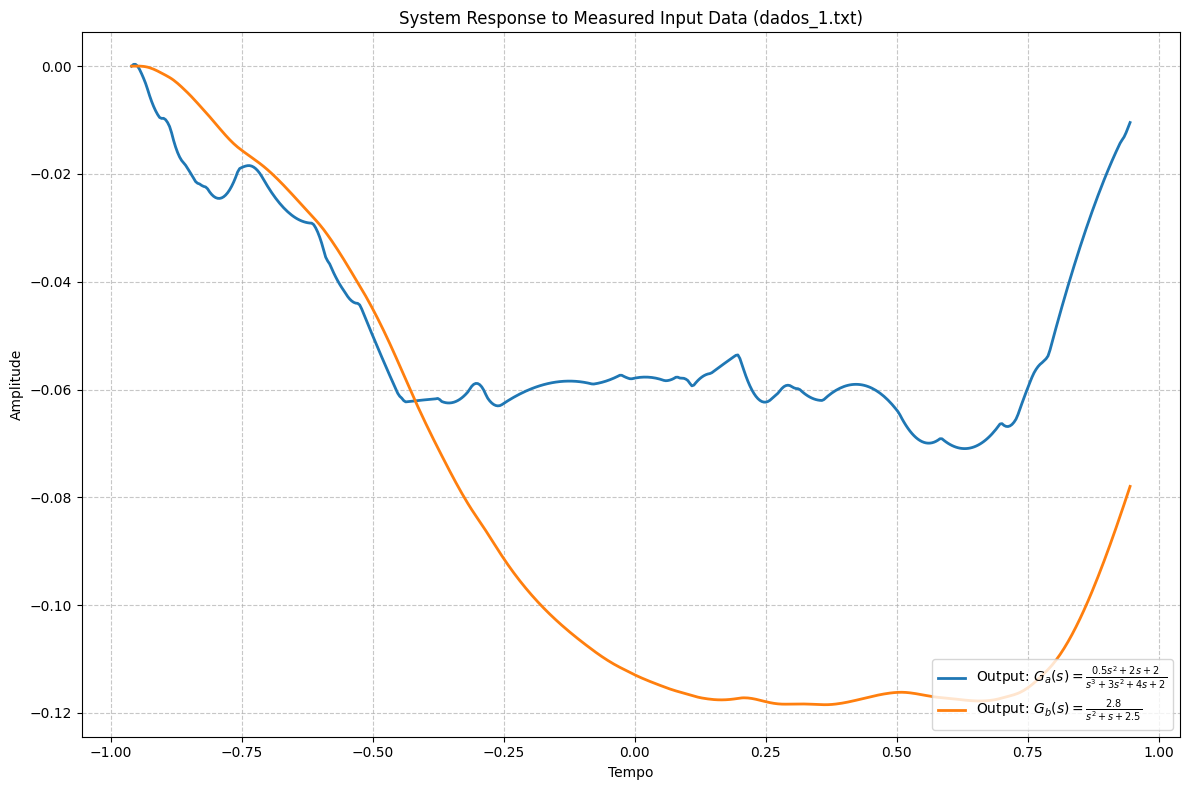

In [23]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

def load_and_resample_dataset(file_path):
    """
    Carrega e reamostra o dataset de entrada.
    """
    u_data, t_data = np.loadtxt(file_path, delimiter=None, unpack=True)

    sort_idx = np.argsort(t_data)
    t_data: float = t_data[sort_idx]
    u_data: float = u_data[sort_idx]
    t_uniform = np.linspace(t_data[0], t_data[-1], len(t_data))
    u_uniform = np.interp(t_uniform, t_data, u_data)
    
    return t_data, u_data, t_uniform, u_uniform



s = ct.tf('s')

ga = (0.5*s**2 + 2*s + 2) / (s**3 + 3*s**2 + 4*s +2)

gb = 2.8 / (s**2 + s + 2.5)

systems = [ga, gb]

labels = [
    r'$G_a(s) = \frac{0.5s^2 + 2s + 2}{s^3 + 3s^2 + 4s + 2}$',
    r'$G_b(s) = \frac{2.8}{s^2 + s + 2.5}$'
]


t_data, u_data, t_uniform, u_uniform = load_and_resample_dataset('dataset/dados_1.txt')

plt.figure(figsize=(12, 8))
#plt.plot(t_data, u_data, label='Input (Measured)', color='black', linestyle=':', alpha=0.5)
#plt.plot(t_uniform, u_uniform, label='Input (Resampled)', color='gray', alpha=0.8)

for sys, label in zip(systems, labels):
    time, response = ct.forced_response(sys, T=t_uniform, U=u_uniform)
    plt.plot(time, response, label=f'Output: {label}', linewidth=2)

plt.title(f'System Response to Measured Input Data (dados_1.txt)')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()